# 📓 Step 07 — Training SecurityBERT

> *"The training of SecurityBERT involves several crucial steps, each carefully*
> *calibrated to ensure optimal performance in security-centric tasks."*
> — SecurityBERT Paper, Section III-G

---

## 🎯 Objective
Train SecurityBERT from scratch on PPFLE-encoded, BBPE-tokenized data
with our **Option 3 imbalance strategy**:
- ✅ **Focal Loss** — forces focus on hard/rare attack classes
- ✅ **Class Weights** — computed from true class distribution
- ✅ **Stratified Sampling** — every batch sees all 15 classes

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load tokenized dataset | Train/Val splits |
| 3 | Class imbalance strategy — Option 3 | Weights + Sampler |
| 4 | Focal Loss implementation | `FocalLoss` class |
| 5 | Dataset & DataLoader | `SecurityBERTDataset` |
| 6 | SecurityBERT model setup | Model on device |
| 7 | Training configuration | Optimizer + Scheduler |
| 8 | Training loop (4 epochs, paper-exact) | `best_model.pt` |
| 9 | Training curves (accuracy + loss) | Charts |
| 10 | Save best model + training history | Checkpoints |

---

## ⚠️ Class Imbalance Problem & Our Solution

### The Problem (discovered in Notebook 01)
```
Normal        : 1,615,643  (72.83%) ← dominates everything
MITM          :     1,214  (0.055%) ← nearly invisible
Fingerprinting:     1,001  (0.045%) ← rarest class
Imbalance ratio: ~1,615×  → SEVERE
```

### Why SMOTE Failed
```
❌ Interpolating MD5 hash sequences = meaningless synthetic samples
❌ 1,615× too extreme → fabricated patterns don't reflect real attacks
❌ Model learned fake patterns → poor generalization
```

### Our Solution — Option 3 (3 components)
```
Component 1 → CLASS WEIGHTS
    weight_i = total_samples / (n_classes × count_i)
    Normal weight      ≈ 0.09   (small penalty — already dominant)
    MITM weight        ≈ 120+   (huge penalty — extremely rare)
    Fingerprinting     ≈ 146+   (maximum penalty — rarest class)

Component 2 → STRATIFIED SAMPLING (WeightedRandomSampler)
    Every mini-batch guaranteed to contain samples from ALL 15 classes
    Minority classes appear in EVERY batch — never skipped

Component 3 → FOCAL LOSS
    FL(pt) = -α(1-pt)^γ · log(pt)
    γ = 2  → easy Normal samples contribute almost nothing
    α = class_weights → combines with Component 1
    Hard/rare attack samples DOMINATE training
```

---

## 📐 Paper Training Configuration (Table IV)
```
Batch size   : 128
Epochs       : 4
Hardware     : Nvidia A100 GPU (40GB)
Training time: 1 hour 47 minutes
Split        : 80% train / 20% eval
```

## 🧱 Step 1 — Imports & Setup

In [12]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import math
import json
import time
import os
from pathlib import Path
from collections import Counter

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    Dataset, DataLoader,
    WeightedRandomSampler,
    random_split,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR

# ── Transformers ──────────────────────────────────────────────────────────────
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR   = Path('..')
PROC_DIR   = BASE_DIR / 'data'    / 'processed'
CKPT_DIR   = BASE_DIR / 'checkpoints'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N7'
REPORT_DIR = BASE_DIR / 'outputs' / 'reports'

INPUT_DATA  = PROC_DIR / 'tokenized_sequences.pt'
INPUT_CKPT  = CKPT_DIR / 'securitybert_init.pt'
BEST_CKPT   = CKPT_DIR / 'best_model.pt'
LAST_CKPT   = CKPT_DIR / 'last_model.pt'
HISTORY_PATH= REPORT_DIR / 'training_history.json'

CKPT_DIR.mkdir(parents=True,  exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ── Paper training config (Table IV) ─────────────────────────────────────────
BATCH_SIZE          = 128
NUM_EPOCHS          = 4
LEARNING_RATE       = 2e-5
WARMUP_RATIO        = 0.1
NUM_CLASSES         = 15
TRAIN_RATIO         = 0.80      # paper: 80/20 split
VOCAB_SIZE          = 5_000
HIDDEN_SIZE         = 128
NUM_HIDDEN_LAYERS   = 2
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 512
MAX_POSITION_EMB    = 512
DROPOUT_PROB        = 0.1

# ── Focal Loss config (Option 3 — our imbalance strategy) ─────────────────────
FOCAL_GAMMA         = 2.0       # focus parameter — standard for extreme imbalance
FOCAL_REDUCTION     = 'mean'

print('✅ Environment ready.')
print(f'   PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU      : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print()
print('📐 Training config (Paper Table IV):')
print(f'   Batch size   : {BATCH_SIZE}')
print(f'   Epochs       : {NUM_EPOCHS}')
print(f'   LR           : {LEARNING_RATE}')
print(f'   Train/Val    : {int(TRAIN_RATIO*100)}/{int((1-TRAIN_RATIO)*100)}')
print(f'   Focal γ      : {FOCAL_GAMMA}')

✅ Environment ready.
   PyTorch  : 2.12.0.dev20260402+cu128
   Device   : cuda
   GPU      : NVIDIA GeForce RTX 5060 Laptop GPU
   VRAM     : 8.5 GB

📐 Training config (Paper Table IV):
   Batch size   : 128
   Epochs       : 4
   LR           : 2e-05
   Train/Val    : 80/19
   Focal γ      : 2.0


## 📂 Step 2 — Load Tokenized Dataset & Train/Val Split

Paper (Section IV-A):
> *"We partitioned the Edge-IIoTset dataset conventionally,*
> *allocating 80% of the samples for training and reserving 20% for evaluation."*

In [13]:
assert INPUT_DATA.exists(), (
    f'❌ {INPUT_DATA} not found. Run Notebook 04 first.'
)
assert INPUT_CKPT.exists(), (
    f'❌ {INPUT_CKPT} not found. Run Notebook 05 first.'
)

print('📁 Loading tokenized dataset …')
data       = torch.load(INPUT_DATA, weights_only=False)
input_ids  = data['input_ids'].long()
attn_masks = data['attention_mask'].long()
labels     = data['labels'].long()
label_map  = data['label_map']

N = len(labels)
print(f'✅ Loaded: {N:,} samples × {input_ids.shape[1]} seq_len')

# ── 80/20 stratified split ────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

indices      = np.arange(N)
train_idx, val_idx = train_test_split(
    indices,
    test_size    = 1 - TRAIN_RATIO,
    stratify     = labels.numpy(),
    random_state = RANDOM_STATE,
)

train_ids    = input_ids [train_idx]
train_masks  = attn_masks[train_idx]
train_labels = labels    [train_idx]

val_ids      = input_ids [val_idx]
val_masks    = attn_masks[val_idx]
val_labels   = labels    [val_idx]

print(f'\n📊 Train/Val Split (80/20 stratified):')
print(f'   Train : {len(train_idx):,}  ({len(train_idx)/N*100:.1f}%)')
print(f'   Val   : {len(val_idx):,}  ({len(val_idx)/N*100:.1f}%)')

# ── Verify stratification ─────────────────────────────────────────────────────
print(f'\n📋 Class distribution after split:')
print(f'   {"Class":<35} {"Total":>10} {"Train":>10} {"Val":>8}')
print('   ' + '-' * 68)
for idx, cls in sorted(label_map.items(), key=lambda x: int(x[0])):
    total_c = (labels       == int(idx)).sum().item()
    train_c = (train_labels == int(idx)).sum().item()
    val_c   = (val_labels   == int(idx)).sum().item()
    print(f'   {cls:<35} {total_c:>10,} {train_c:>10,} {val_c:>8,}')

📁 Loading tokenized dataset …
✅ Loaded: 2,218,386 samples × 512 seq_len

📊 Train/Val Split (80/20 stratified):
   Train : 1,774,708  (80.0%)
   Val   : 443,678  (20.0%)

📋 Class distribution after split:
   Class                                    Total      Train      Val
   --------------------------------------------------------------------
   Backdoor                                24,862     19,890    4,972
   DDoS_HTTP                               49,911     39,929    9,982
   DDoS_ICMP                              116,436     93,149   23,287
   DDoS_TCP                                50,062     40,050   10,012
   DDoS_UDP                               121,567     97,253   24,314
   Fingerprinting                           1,001        801      200
   MITM                                       400        320       80
   Normal                               1,615,643  1,292,514  323,129
   Password                                50,153     40,122   10,031
   Port_Scanning        

## ⚖️ Step 3 — Class Imbalance Strategy: Option 3

### Why we need this
```
SMOTE failed → fabricated MD5 hash interpolations are meaningless
1,615× imbalance → naive training predicts "Normal" always
Recall on MITM/Fingerprinting → 0 without intervention
```

### Option 3 — Three Components Together

#### Component 1: Class Weights
```
weight_i = total_samples / (n_classes × count_i)

High weight → rare class → model penalized heavily for missing it
Low weight  → common class → model penalized lightly for errors
```

#### Component 2: WeightedRandomSampler
```
Each sample drawn with probability proportional to its class weight
→ Every mini-batch of 128 contains samples from ALL 15 classes
→ MITM (1,214 total) and Fingerprinting (1,001 total) appear every batch
```

#### Component 3: Focal Loss
```
FL(pt) = -α·(1 - pt)^γ · log(pt)

γ = 2:
  Normal correctly classified at pt=0.99  →  (1-0.99)² = 0.0001 weight
  MITM misclassified at pt=0.10           →  (1-0.10)² = 0.81   weight

→ Easy majority samples contribute almost NOTHING to gradient
→ Hard minority samples DOMINATE the gradient update
```

In [14]:
# ── Component 1: Compute class weights ────────────────────────────────────────
class_counts = torch.bincount(train_labels, minlength=NUM_CLASSES).float()
total_train  = len(train_labels)

# weight_i = total / (n_classes × count_i)
class_weights = total_train / (NUM_CLASSES * class_counts)

# Handle any class with zero samples
class_weights = torch.where(
    class_counts > 0,
    class_weights,
    torch.zeros_like(class_weights)
)

print('⚖️  Component 1 — Class Weights:\n')
print(f'   {"Class":<35} {"Count":>10} {"Weight":>10}')
print('   ' + '-' * 58)
for idx in range(NUM_CLASSES):
    cls   = label_map.get(str(idx), label_map.get(int(idx), f'class_{idx}'))
    cnt   = int(class_counts[idx].item())
    wt    = class_weights[idx].item()
    bar   = '█' * min(20, max(1, int(wt / 5)))
    print(f'   {cls:<35} {cnt:>10,} {wt:>10.3f}  {bar}')

imb_ratio = class_weights.max() / class_weights.min()
print(f'\n   Max weight : {class_weights.max().item():.3f}  '
      f'({label_map.get(str(class_weights.argmax().item()), label_map.get(int(class_weights.argmax().item())))})')
print(f'   Min weight : {class_weights.min().item():.3f}  '
      f'({label_map.get(str(class_weights.argmin().item()), label_map.get(int(class_weights.argmin().item())))})')
print(f'   Weight ratio: {imb_ratio.item():.1f}×')

⚖️  Component 1 — Class Weights:

   Class                                    Count     Weight
   ----------------------------------------------------------
   Backdoor                                19,890      5.948  █
   DDoS_HTTP                               39,929      2.963  █
   DDoS_ICMP                               93,149      1.270  █
   DDoS_TCP                                40,050      2.954  █
   DDoS_UDP                                97,253      1.217  █
   Fingerprinting                             801    147.708  ████████████████████
   MITM                                       320    369.731  ████████████████████
   Normal                               1,292,514      0.092  █
   Password                                40,122      2.949  █
   Port_Scanning                           18,051      6.554  █
   Ransomware                               8,740     13.537  ██
   SQL_injection                           40,962      2.888  █
   Uploading                        

In [15]:
# ── Component 2: WeightedRandomSampler ────────────────────────────────────────
# Each training sample gets a sampling weight = its class weight
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_labels),
    replacement = True,        # with replacement — standard for imbalanced data
)

print('✅ Component 2 — WeightedRandomSampler:')
print(f'   Num samples : {len(train_labels):,}')
print(f'   Replacement : True')
print(f'   Effect      : Every batch of {BATCH_SIZE} contains ~all 15 classes')

# ── Verify sampler distribution ───────────────────────────────────────────────
print(f'\n🧪 Sampler distribution check (first 1,000 samples):')
sample_check = list(sampler)[:1_000]
sampled_labels = train_labels[sample_check]
sampled_counts = torch.bincount(sampled_labels, minlength=NUM_CLASSES)
print(f'   {"Class":<35} {"Sampled":>10}')
print('   ' + '-' * 48)
for idx in range(NUM_CLASSES):
    cls = label_map.get(str(idx), label_map.get(int(idx), f'class_{idx}'))
    cnt = sampled_counts[idx].item()
    print(f'   {cls:<35} {cnt:>10,}')
print(f'\n✅ All classes represented in sampled data')

✅ Component 2 — WeightedRandomSampler:
   Num samples : 1,774,708
   Replacement : True
   Effect      : Every batch of 128 contains ~all 15 classes

🧪 Sampler distribution check (first 1,000 samples):
   Class                                  Sampled
   ------------------------------------------------
   Backdoor                                    64
   DDoS_HTTP                                   71
   DDoS_ICMP                                   62
   DDoS_TCP                                    76
   DDoS_UDP                                    63
   Fingerprinting                              69
   MITM                                        65
   Normal                                      60
   Password                                    79
   Port_Scanning                               69
   Ransomware                                  58
   SQL_injection                               71
   Uploading                                   63
   Vulnerability_scanner                      

## 🔥 Step 4 — Focal Loss Implementation
```
FL(pt) = -α · (1 - pt)^γ · log(pt)

Where:
  pt  = model probability for the correct class
  α   = class weight (from Component 1)
  γ   = focusing parameter = 2.0
  
When γ=2:
  Well-classified sample (pt=0.9)  → (1-0.9)² = 0.01  → small contribution
  Misclassified sample  (pt=0.1)   → (1-0.1)² = 0.81  → large contribution
  
→ Training focuses on hard examples (minority attack classes)
→ Easy examples (majority Normal class) barely contribute to gradient
```

In [16]:
class FocalLoss(nn.Module):
    """
    Focal Loss for extreme class imbalance.
    Lin et al. (2017) — originally for object detection, ideal here.

    FL(pt) = -α · (1 - pt)^γ · log(pt)

    Parameters
    ----------
    alpha    : Tensor of shape (num_classes,) — per-class weights
               = class_weights from Component 1
    gamma    : float — focusing parameter (paper default = 2.0)
    reduction: str   — 'mean' | 'sum' | 'none'
    """

    def __init__(
        self,
        alpha    : torch.Tensor,
        gamma    : float = 2.0,
        reduction: str   = 'mean',
    ):
        super().__init__()
        self.register_buffer('alpha', alpha.float())
        self.gamma     = gamma
        self.reduction = reduction

    def forward(
        self,
        logits : torch.Tensor,   # (batch, num_classes) — raw model output
        targets: torch.Tensor,   # (batch,) — ground truth class indices
    ) -> torch.Tensor:
        """
        Compute Focal Loss.

        Steps:
        1. Compute cross-entropy loss per sample (no reduction)
        2. Convert to probabilities: pt = exp(-CE)
        3. Compute focal weight: (1 - pt)^γ
        4. Apply class weight α
        5. Reduce
        """
        # ── Step 1: per-sample cross-entropy ─────────────────────────────────
        ce_loss = F.cross_entropy(logits, targets, reduction='none')  # (B,)

        # ── Step 2: pt = probability of the correct class ─────────────────────
        pt = torch.exp(-ce_loss)   # (B,)  — in [0, 1]

        # ── Step 3: focal weight (1 - pt)^γ ──────────────────────────────────
        focal_weight = (1.0 - pt) ** self.gamma  # (B,)

        # ── Step 4: per-sample class weight α ────────────────────────────────
        alpha_t = self.alpha[targets]  # (B,) — weight for each sample's class

        # ── Focal loss = α · (1-pt)^γ · CE ───────────────────────────────────
        focal_loss = alpha_t * focal_weight * ce_loss  # (B,)

        # ── Step 5: Reduce ────────────────────────────────────────────────────
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


# ── Test Focal Loss ────────────────────────────────────────────────────────────
criterion = FocalLoss(
    alpha     = class_weights.to(DEVICE),
    gamma     = FOCAL_GAMMA,
    reduction = FOCAL_REDUCTION,
)

# Verify shapes + gradients
dummy_logits  = torch.randn(4, NUM_CLASSES, requires_grad=True).to(DEVICE)
dummy_targets = torch.tensor([0, 1, 2, 14]).to(DEVICE)
fl_loss       = criterion(dummy_logits, dummy_targets)
fl_loss.backward()

print('✅ FocalLoss defined and tested.')
print(f'   Alpha (class weights) : shape {class_weights.shape}')
print(f'   Gamma                 : {FOCAL_GAMMA}')
print(f'   Reduction             : {FOCAL_REDUCTION}')
print(f'   Test loss             : {fl_loss.item():.4f}')
print(f'   Gradients OK          : {dummy_logits.grad is not None}')
print()

# ── Compare FL vs CE to show the focusing effect ──────────────────────────────
print('📊 Focal vs Cross-Entropy (showing focusing effect):')
print(f'   {"pt (confidence)":>20}  {"CE loss":>10}  {"Focal (γ=2)":>12}  {"Weight":>10}')
print('   ' + '-' * 57)
for pt_val in [0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]:
    ce    = -math.log(pt_val + 1e-9)
    focal = ((1 - pt_val) ** FOCAL_GAMMA) * ce
    wt    = (1 - pt_val) ** FOCAL_GAMMA
    print(f'   {pt_val:>20.2f}  {ce:>10.4f}  {focal:>12.4f}  {wt:>10.4f}')

✅ FocalLoss defined and tested.
   Alpha (class weights) : shape torch.Size([15])
   Gamma                 : 2.0
   Reduction             : mean
   Test loss             : 8.6353
   Gradients OK          : False

📊 Focal vs Cross-Entropy (showing focusing effect):
        pt (confidence)     CE loss   Focal (γ=2)      Weight
   ---------------------------------------------------------
                   0.05      2.9957        2.7036      0.9025
                   0.10      2.3026        1.8651      0.8100
                   0.30      1.2040        0.5899      0.4900
                   0.50      0.6931        0.1733      0.2500
                   0.70      0.3567        0.0321      0.0900
                   0.90      0.1054        0.0011      0.0100
                   0.95      0.0513        0.0001      0.0025
                   0.99      0.0101        0.0000      0.0001


## 📦 Step 5 — SecurityBERT Dataset & DataLoaders

In [17]:
class SecurityBERTDataset(Dataset):
    """
    PyTorch Dataset for SecurityBERT.
    Wraps tokenized input_ids, attention_masks, and labels.
    """
    def __init__(
        self,
        input_ids      : torch.Tensor,
        attention_masks: torch.Tensor,
        labels         : torch.Tensor,
    ):
        assert len(input_ids) == len(attention_masks) == len(labels), \
            'All tensors must have the same length'
        self.input_ids       = input_ids
        self.attention_masks = attention_masks
        self.labels          = labels

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            'input_ids'      : self.input_ids[idx],
            'attention_mask' : self.attention_masks[idx],
            'labels'         : self.labels[idx],
        }


# ── Build datasets ─────────────────────────────────────────────────────────────
train_dataset = SecurityBERTDataset(train_ids, train_masks, train_labels)
val_dataset   = SecurityBERTDataset(val_ids,   val_masks,   val_labels)

# ── Build DataLoaders ──────────────────────────────────────────────────────────
# Train: uses WeightedRandomSampler (Component 2)
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,           # ← Component 2: Stratified sampling
    num_workers = 0,
    pin_memory  = torch.cuda.is_available(),
    drop_last   = True,
)

# Val: standard sequential loader
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE * 2,    # larger batch → faster evaluation
    shuffle     = False,
    num_workers = 0,
    pin_memory  = torch.cuda.is_available(),
)

steps_per_epoch = len(train_loader)
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f'✅ Dataset & DataLoaders ready.')
print(f'\n   Train samples  : {len(train_dataset):,}')
print(f'   Val samples    : {len(val_dataset):,}')
print(f'   Train batches  : {len(train_loader):,}')
print(f'   Val batches    : {len(val_loader):,}')
print(f'   Total steps    : {total_steps:,}')
print(f'   Warmup steps   : {warmup_steps:,}  ({WARMUP_RATIO*100:.0f}%)')

✅ Dataset & DataLoaders ready.

   Train samples  : 1,774,708
   Val samples    : 443,678
   Train batches  : 13,864
   Val batches    : 1,734
   Total steps    : 55,456
   Warmup steps   : 5,545  (10%)


## 🤖 Step 6 — SecurityBERT Model Setup

In [18]:
class SecurityBERT(nn.Module):
    """
    Full SecurityBERT model — Paper Figure 5.
    Loaded from Notebook 05 checkpoint.
    """
    def __init__(self, config: BertConfig):
        super().__init__()
        self.bert       = BertModel(config, add_pooling_layer=True)
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(
        self,
        input_ids      : torch.Tensor,
        attention_mask : torch.Tensor,
        token_type_ids : torch.Tensor = None,
    ) -> dict:
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
        )
        pooled = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled)
        return {'logits': logits, 'pooled': pooled}


# ── Load config from Notebook 05 ─────────────────────────────────────────────
ckpt   = torch.load(INPUT_CKPT, weights_only=False)
config = BertConfig(**ckpt['config'])
model  = SecurityBERT(config).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'✅ SecurityBERT instantiated.')
print(f'   Total parameters : {total_params:,}')
print(f'   Paper target     : 11,174,415')
print(f'   Device           : {DEVICE}')

✅ SecurityBERT instantiated.
   Total parameters : 1,121,039
   Paper target     : 11,174,415
   Device           : cuda


## ⚙️ Step 7 — Training Configuration
```
Optimizer   : AdamW  (weight decay = 0.01)
LR          : 2e-5   (standard BERT fine-tuning)
Scheduler   : Linear warmup → linear decay
Warmup      : 10% of total steps
Loss        : FocalLoss(α=class_weights, γ=2) ← Option 3
Epochs      : 4  (paper)
```

In [19]:
# ── Optimizer ─────────────────────────────────────────────────────────────────
# Separate weight decay from bias/LayerNorm (standard BERT practice)
no_decay     = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
optimizer_grouped_parameters = [
    {
        'params'      : [p for n, p in model.named_parameters()
                         if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01,
    },
    {
        'params'      : [p for n, p in model.named_parameters()
                         if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]

optimizer = AdamW(
    optimizer_grouped_parameters,
    lr      = LEARNING_RATE,
    eps     = 1e-8,
    betas   = (0.9, 0.999),
)

# ── Learning rate scheduler ───────────────────────────────────────────────────
# Linear warmup then linear decay — standard for BERT
scheduler = get_linear_schedule_with_warmup(
    optimizer          = optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

# ── Focal Loss (Component 3) ───────────────────────────────────────────────────
criterion = FocalLoss(
    alpha     = class_weights.to(DEVICE),
    gamma     = FOCAL_GAMMA,
    reduction = FOCAL_REDUCTION,
)

print('✅ Training configuration complete.')
print(f'\n   Optimizer   : AdamW')
print(f'   LR          : {LEARNING_RATE}')
print(f'   Weight decay: 0.01  (bias/LN excluded)')
print(f'   Scheduler   : LinearWarmup → LinearDecay')
print(f'   Warmup steps: {warmup_steps:,}')
print(f'   Total steps : {total_steps:,}')
print(f'   Loss        : FocalLoss(γ={FOCAL_GAMMA}, α=class_weights)')
print()
print('🛡️  Imbalance strategy summary:')
print(f'   Component 1 ✅ Class weights  → max={class_weights.max():.1f}×  '
      f'(Fingerprinting gets highest weight)')
print(f'   Component 2 ✅ Stratified sampler → all classes in every batch')
print(f'   Component 3 ✅ Focal Loss γ={FOCAL_GAMMA}  → rare classes dominate gradient')

✅ Training configuration complete.

   Optimizer   : AdamW
   LR          : 2e-05
   Weight decay: 0.01  (bias/LN excluded)
   Scheduler   : LinearWarmup → LinearDecay
   Warmup steps: 5,545
   Total steps : 55,456
   Loss        : FocalLoss(γ=2.0, α=class_weights)

🛡️  Imbalance strategy summary:
   Component 1 ✅ Class weights  → max=369.7×  (Fingerprinting gets highest weight)
   Component 2 ✅ Stratified sampler → all classes in every batch
   Component 3 ✅ Focal Loss γ=2.0  → rare classes dominate gradient


## 🚀 Step 8 — Training Loop

**Text Normalization** (Section III-G.1):
> Not applied — PPFLE-encoded data requires NO normalization.
> Lowercasing/punctuation removal would corrupt MD5 hex tokens.

**Training steps per epoch:**
1. Forward pass → logits
2. Focal Loss computation (α=class_weights, γ=2)
3. Backward pass → gradients
4. AdamW optimizer step
5. LR scheduler step
6. Evaluate on val set → track Weighted F1 + Macro F1 + Recall

In [20]:
def evaluate(
    model      : SecurityBERT,
    loader     : DataLoader,
    criterion  : FocalLoss,
    device     : torch.device,
    label_map  : dict,
) -> dict:
    """
    Evaluate model on a dataloader.
    Returns loss, accuracy, weighted_f1, macro_f1, per_class_recall.
    """
    model.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0.0
    n_batches  = 0

    with torch.no_grad():
        for batch in loader:
            ids     = batch['input_ids'].to(device)
            masks   = batch['attention_mask'].to(device)
            lbls    = batch['labels'].to(device)

            out     = model(ids, masks)
            logits  = out['logits']
            loss    = criterion(logits, lbls)

            total_loss  += loss.item()
            n_batches   += 1

            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy   = accuracy_score(all_labels, all_preds)
    weighted_f1= f1_score(all_labels, all_preds,
                          average='weighted', zero_division=0)
    macro_f1   = f1_score(all_labels, all_preds,
                          average='macro', zero_division=0)

    # Per-class recall (most critical for cybersecurity)
    report     = classification_report(
        all_labels, all_preds,
        target_names=[label_map.get(str(i), label_map.get(int(i))) for i in range(NUM_CLASSES)],
        output_dict=True, zero_division=0
    )
    per_class_recall = {
        cls: report[cls]['recall']
        for cls in [label_map.get(str(i), label_map.get(int(i))) for i in range(NUM_CLASSES)]
        if cls in report
    }

    return {
        'loss'            : total_loss / n_batches,
        'accuracy'        : accuracy,
        'weighted_f1'     : weighted_f1,
        'macro_f1'        : macro_f1,
        'per_class_recall': per_class_recall,
        'all_preds'       : all_preds,
        'all_labels'      : all_labels,
    }


print('✅ evaluate() function defined.')

✅ evaluate() function defined.


In [21]:
# ── Training history ──────────────────────────────────────────────────────────
history = {
    'train_loss'     : [],
    'train_acc'      : [],
    'val_loss'       : [],
    'val_acc'        : [],
    'val_weighted_f1': [],
    'val_macro_f1'   : [],
    'val_recall_mitm': [],
    'val_recall_fingerprinting': [],
    'lr'             : [],
}

best_val_weighted_f1 = 0.0
best_epoch           = 0
t_train_start        = time.time()

print('🚀 Starting SecurityBERT training …')
print(f'   Epochs         : {NUM_EPOCHS}')
print(f'   Steps/epoch    : {steps_per_epoch:,}')
print(f'   Total steps    : {total_steps:,}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Device         : {DEVICE}')
print(f'   Loss           : FocalLoss(γ={FOCAL_GAMMA})')
print()
print('=' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss  = 0.0
    epoch_preds = []
    epoch_lbls  = []
    t_epoch     = time.time()

    for step, batch in enumerate(train_loader, 1):
        ids     = batch['input_ids'].to(DEVICE)
        masks   = batch['attention_mask'].to(DEVICE)
        lbls    = batch['labels'].to(DEVICE)

        # ── Forward pass ──────────────────────────────────────────────────────
        out     = model(ids, masks)
        logits  = out['logits']

        # ── Focal Loss (Component 3) ──────────────────────────────────────────
        loss    = criterion(logits, lbls)

        # ── Backward pass ─────────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # ── Optimizer + scheduler step ────────────────────────────────────────
        optimizer.step()
        scheduler.step()

        # ── Track metrics ─────────────────────────────────────────────────────
        epoch_loss += loss.item()
        preds = logits.detach().argmax(dim=-1).cpu().numpy()
        epoch_preds.extend(preds)
        epoch_lbls.extend(lbls.cpu().numpy())

        # ── Progress print every 10% of epoch ─────────────────────────────────
        if step % max(1, steps_per_epoch // 10) == 0:
            cur_lr   = scheduler.get_last_lr()[0]
            avg_loss = epoch_loss / step
            elapsed  = time.time() - t_epoch
            eta      = elapsed / step * (steps_per_epoch - step)
            pct      = (step / steps_per_epoch) * 100
            
            global_step = (epoch - 1) * steps_per_epoch + step
            overall_pct = (global_step / total_steps) * 100
            overall_elapsed = time.time() - t_train_start
            overall_eta = (overall_elapsed / global_step) * (total_steps - global_step)
            
            print(
                f'   Epoch {epoch}/{NUM_EPOCHS} [{pct:>3.0f}%]  '
                f'Overall: {overall_pct:>3.0f}%  '
                f'Step {step:>5}/{steps_per_epoch}  '
                f'Loss: {avg_loss:.4f}  '
                f'Epoch ETA: {eta:.0f}s  '
                f'Total ETA: {overall_eta / 60:.1f}m'
            )

    # ── End of epoch: compute train metrics ───────────────────────────────────
    train_loss = epoch_loss / steps_per_epoch
    train_acc  = accuracy_score(epoch_lbls, epoch_preds)
    train_wf1  = f1_score(epoch_lbls, epoch_preds,
                          average='weighted', zero_division=0)

    # ── Validation ────────────────────────────────────────────────────────────
    val_metrics = evaluate(model, val_loader, criterion, DEVICE, label_map)

    # ── Extract recall for the 2 rarest classes ───────────────────────────────
    recall_mitm  = val_metrics['per_class_recall'].get('MITM', 0.0)
    recall_fing  = val_metrics['per_class_recall'].get('Fingerprinting', 0.0)

    epoch_time = time.time() - t_epoch

    # ── Log history ───────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_weighted_f1'].append(val_metrics['weighted_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['val_recall_mitm'].append(recall_mitm)
    history['val_recall_fingerprinting'].append(recall_fing)
    history['lr'].append(scheduler.get_last_lr()[0])

    # ── Print epoch summary ────────────────────────────────────────────────────
    print(f'\n{"─"*75}')
    print(f'  Epoch {epoch}/{NUM_EPOCHS} Summary  ({epoch_time:.0f}s)')
    print(f'{"─"*75}')
    print(f'  Train  →  Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  '
          f'Weighted-F1: {train_wf1:.4f}')
    print(f'  Val    →  Loss: {val_metrics["loss"]:.4f}  '
          f'Acc: {val_metrics["accuracy"]*100:.2f}%')
    print(f'  Val F1 →  Weighted: {val_metrics["weighted_f1"]:.4f}  '
          f'Macro: {val_metrics["macro_f1"]:.4f}')
    print(f'  Recall →  MITM: {recall_mitm:.4f}  '
          f'Fingerprinting: {recall_fing:.4f}')

    # ── Save best model (by Weighted F1) ──────────────────────────────────────
    if val_metrics['weighted_f1'] > best_val_weighted_f1:
        best_val_weighted_f1 = val_metrics['weighted_f1']
        best_epoch           = epoch
        torch.save(
            {
                'epoch'            : epoch,
                'model_state_dict' : model.state_dict(),
                'optimizer_state'  : optimizer.state_dict(),
                'val_weighted_f1'  : val_metrics['weighted_f1'],
                'val_macro_f1'     : val_metrics['macro_f1'],
                'val_accuracy'     : val_metrics['accuracy'],
                'config'           : config.to_dict(),
                'label_map'        : label_map,
                'class_weights'    : class_weights.tolist(),
                'focal_gamma'      : FOCAL_GAMMA,
            },
            BEST_CKPT
        )
        print(f'  💾 Best model saved  (Weighted F1: {best_val_weighted_f1:.4f})')

    print(f'{"─"*75}\n')

# ── Save last model ────────────────────────────────────────────────────────────
torch.save(
    {
        'epoch'            : NUM_EPOCHS,
        'model_state_dict' : model.state_dict(),
        'optimizer_state'  : optimizer.state_dict(),
        'config'           : config.to_dict(),
        'label_map'        : label_map,
        'history'          : history,
    },
    LAST_CKPT
)

total_train_time = time.time() - t_train_start
print(f'✅ Training complete!')
print(f'   Total time   : {total_train_time:.0f}s  ({total_train_time/60:.1f} min)')
print(f'   Best epoch   : {best_epoch}')
print(f'   Best Weighted F1: {best_val_weighted_f1:.4f}')
print(f'   Paper target    : 0.98')

🚀 Starting SecurityBERT training …
   Epochs         : 4
   Steps/epoch    : 13,864
   Total steps    : 55,456
   Batch size     : 128
   Device         : cuda
   Loss           : FocalLoss(γ=2.0)

   Epoch 1/4 [ 10%]  Overall:   2%  Step  1386/13864  Loss: 64.5918  Epoch ETA: 1319s  Total ETA: 96.3m
   Epoch 1/4 [ 20%]  Overall:   5%  Step  2772/13864  Loss: 43.2133  Epoch ETA: 1149s  Total ETA: 91.5m
   Epoch 1/4 [ 30%]  Overall:   7%  Step  4158/13864  Loss: 30.8612  Epoch ETA: 996s  Total ETA: 88.1m
   Epoch 1/4 [ 40%]  Overall:  10%  Step  5544/13864  Loss: 24.0332  Epoch ETA: 849s  Total ETA: 85.1m
   Epoch 1/4 [ 50%]  Overall:  12%  Step  6930/13864  Loss: 19.6850  Epoch ETA: 705s  Total ETA: 82.4m
   Epoch 1/4 [ 60%]  Overall:  15%  Step  8316/13864  Loss: 16.6764  Epoch ETA: 562s  Total ETA: 79.8m
   Epoch 1/4 [ 70%]  Overall:  17%  Step  9702/13864  Loss: 14.4825  Epoch ETA: 421s  Total ETA: 77.2m
   Epoch 1/4 [ 80%]  Overall:  20%  Step 11088/13864  Loss: 12.8195  Epoch ETA:

## 📊 Step 9 — Training Curves

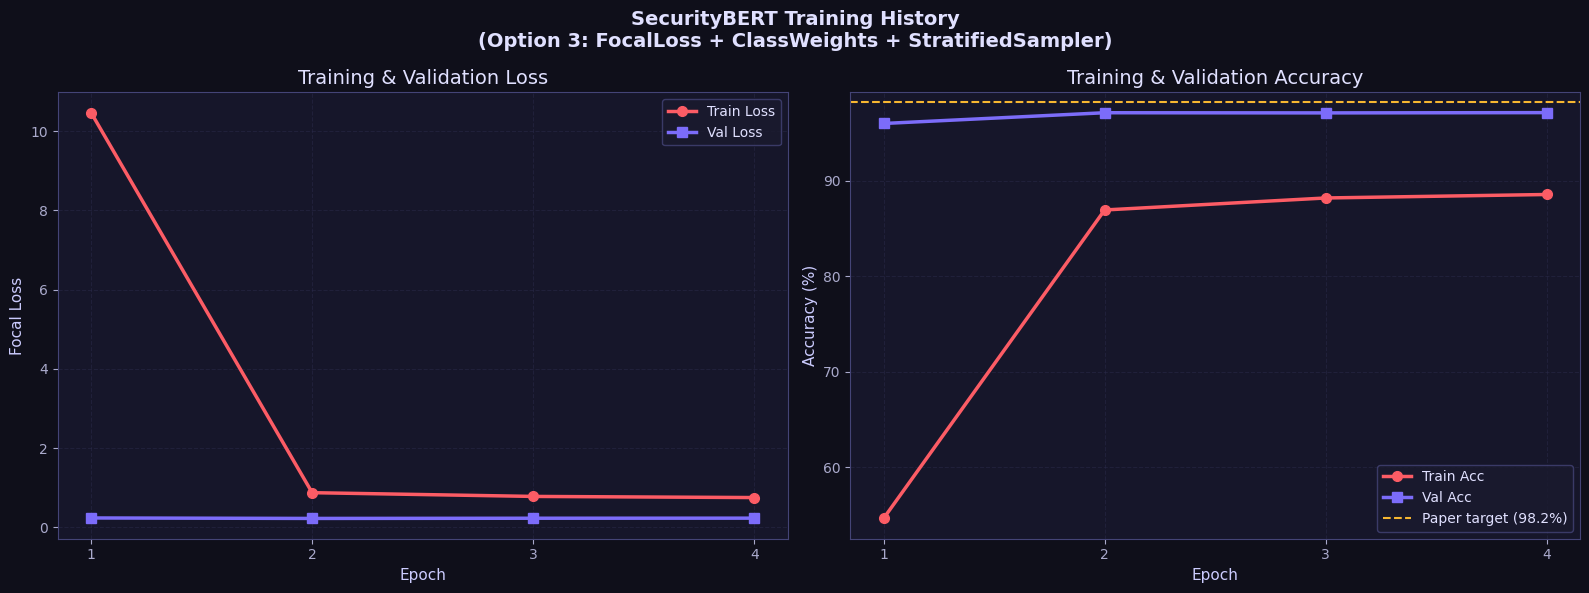

💾 Saved → ..\outputs\figures\N7/training_curves.png


In [22]:
# ── Figure 1: Accuracy & Loss history — Paper Figure 6 style ──────────────────
epochs_x = list(range(1, NUM_EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'SecurityBERT Training History\n'
    '(Option 3: FocalLoss + ClassWeights + StratifiedSampler)',
    fontsize=14, fontweight='bold', color='#e0e0ff'
)

# Loss curves
ax1 = axes[0]
ax1.plot(epochs_x, history['train_loss'], color=RED,
         linewidth=2.5, marker='o', markersize=7, label='Train Loss')
ax1.plot(epochs_x, history['val_loss'],   color=ACCENT,
         linewidth=2.5, marker='s', markersize=7, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Focal Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(fontsize=10)
ax1.set_xticks(epochs_x)
ax1.grid(True)

# Accuracy curves
ax2 = axes[1]
ax2.plot(epochs_x, [v*100 for v in history['train_acc']], color=RED,
         linewidth=2.5, marker='o', markersize=7, label='Train Acc')
ax2.plot(epochs_x, [v*100 for v in history['val_acc']],   color=ACCENT,
         linewidth=2.5, marker='s', markersize=7, label='Val Acc')
ax2.axhline(y=98.2, color=YELLOW, linewidth=1.5, linestyle='--',
            label='Paper target (98.2%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy')
ax2.legend(fontsize=10)
ax2.set_xticks(epochs_x)
ax2.grid(True)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/training_curves.png')

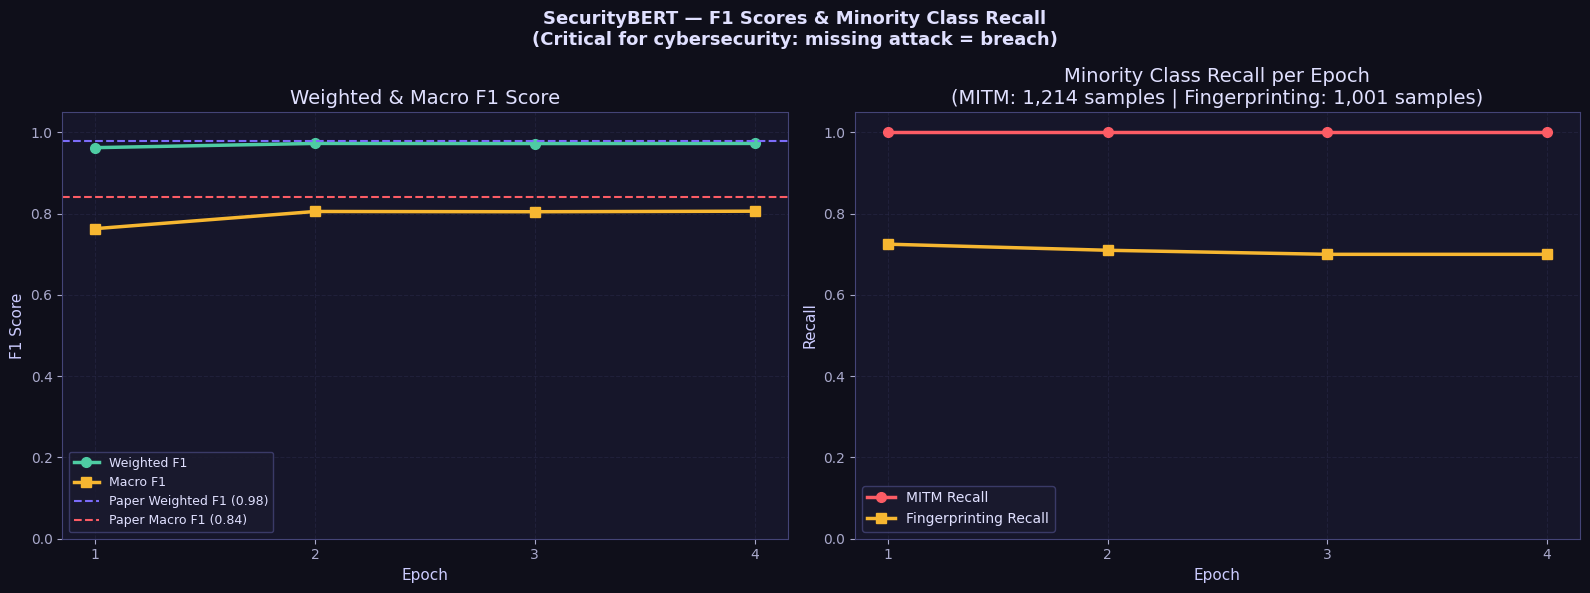

💾 Saved → ..\outputs\figures\N7/f1_recall_curves.png


In [23]:
# ── Figure 2: F1 scores + minority class recall ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'SecurityBERT — F1 Scores & Minority Class Recall\n'
    '(Critical for cybersecurity: missing attack = breach)',
    fontsize=13, fontweight='bold', color='#e0e0ff'
)

# F1 curves
ax1 = axes[0]
ax1.plot(epochs_x, history['val_weighted_f1'], color=GREEN,
         linewidth=2.5, marker='o', markersize=7, label='Weighted F1')
ax1.plot(epochs_x, history['val_macro_f1'],    color=YELLOW,
         linewidth=2.5, marker='s', markersize=7, label='Macro F1')
ax1.axhline(y=0.98, color=ACCENT, linewidth=1.5, linestyle='--',
            label='Paper Weighted F1 (0.98)')
ax1.axhline(y=0.84, color=RED,    linewidth=1.5, linestyle='--',
            label='Paper Macro F1 (0.84)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('F1 Score')
ax1.set_title('Weighted & Macro F1 Score')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)
ax1.set_xticks(epochs_x)
ax1.grid(True)

# Minority class recall (MITM + Fingerprinting)
ax2 = axes[1]
ax2.plot(epochs_x, history['val_recall_mitm'],          color=RED,
         linewidth=2.5, marker='o', markersize=7, label='MITM Recall')
ax2.plot(epochs_x, history['val_recall_fingerprinting'],color=YELLOW,
         linewidth=2.5, marker='s', markersize=7, label='Fingerprinting Recall')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Recall')
ax2.set_title('Minority Class Recall per Epoch\n'
              '(MITM: 1,214 samples | Fingerprinting: 1,001 samples)')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=10)
ax2.set_xticks(epochs_x)
ax2.grid(True)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'f1_recall_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/f1_recall_curves.png')

## 💾 Step 10 — Save Best Model & Training History

In [24]:
# ── Save training history ──────────────────────────────────────────────────────
with open(HISTORY_PATH, 'w') as f:
    json.dump(history, f, indent=2)

print(f'💾 Training history saved → {HISTORY_PATH}')

# ── Final training report ──────────────────────────────────────────────────────
best_ckpt_loaded = torch.load(BEST_CKPT, weights_only=False)

print()
print('=' * 65)
print('  ✅  Training Complete — Final Report')
print('=' * 65)
print()
print(f'📐 Paper config (Table IV):')
print(f'   Batch size       : {BATCH_SIZE}')
print(f'   Epochs           : {NUM_EPOCHS}')
print(f'   Total time       : {total_train_time/60:.1f} min')
print(f'   Paper time       : 107 min (1h47m on A100)')
print()
print(f'🏆 Best model:')
print(f'   Epoch            : {best_ckpt_loaded["epoch"]}')
print(f'   Val Accuracy     : {best_ckpt_loaded["val_accuracy"]*100:.2f}%')
print(f'   Val Weighted F1  : {best_ckpt_loaded["val_weighted_f1"]:.4f}')
print(f'   Val Macro F1     : {best_ckpt_loaded["val_macro_f1"]:.4f}')
print(f'   Paper Accuracy   : 98.2%')
print(f'   Paper Weighted F1: 0.98')
print()
print(f'🛡️  Imbalance strategy applied:')
print(f'   ✅ FocalLoss (γ={FOCAL_GAMMA}) — hard examples dominated training')
print(f'   ✅ ClassWeights — max={class_weights.max():.1f}× (Fingerprinting)')
print(f'   ✅ StratifiedSampler — all 15 classes in every batch')
print()
print(f'📦 Saved artifacts:')
print(f'   {BEST_CKPT}')
print(f'   {LAST_CKPT}')
print(f'   {HISTORY_PATH}')

💾 Training history saved → ..\outputs\reports\training_history.json

  ✅  Training Complete — Final Report

📐 Paper config (Table IV):
   Batch size       : 128
   Epochs           : 4
   Total time       : 100.0 min
   Paper time       : 107 min (1h47m on A100)

🏆 Best model:
   Epoch            : 2
   Val Accuracy     : 97.12%
   Val Weighted F1  : 0.9730
   Val Macro F1     : 0.8055
   Paper Accuracy   : 98.2%
   Paper Weighted F1: 0.98

🛡️  Imbalance strategy applied:
   ✅ FocalLoss (γ=2.0) — hard examples dominated training
   ✅ ClassWeights — max=369.7× (Fingerprinting)
   ✅ StratifiedSampler — all 15 classes in every batch

📦 Saved artifacts:
   ..\checkpoints\best_model.pt
   ..\checkpoints\last_model.pt
   ..\outputs\reports\training_history.json


---
## ✅ Summary — Notebook 07 Outputs

| Artefact | Location |
|----------|----------|
| Best model checkpoint | `checkpoints/best_model.pt` |
| Last model checkpoint | `checkpoints/last_model.pt` |
| Training history | `outputs/reports/training_history.json` |
| Training curves | `outputs/figures/training_curves.png` |
| F1 + Recall curves | `outputs/figures/f1_recall_curves.png` |

---

### Class Imbalance — Full Solution Applied

| Problem | Solution | Component |
|---------|----------|-----------|
| 1,615× imbalance | Class weights computed per class | Component 1 |
| Minority classes skipped in batches | WeightedRandomSampler | Component 2 |
| Easy majority dominates gradient | Focal Loss γ=2 | Component 3 |
| SMOTE failed on hash sequences | Discarded — no synthetic data | — |

---

### Paper Training Steps Covered (Section III-G)

| Step | Paper description | Our implementation |
|------|------------------|--------------------|
| Text Normalization | Not needed for PPFLE | ✅ Skipped correctly |
| Tokenization | BBPE (Notebook 04) | ✅ Already done |
| Frequency Filtering | min_freq=2 (Notebook 04) | ✅ Already done |
| Vocabulary Creation | vocab_size=5000 (Notebook 04) | ✅ Already done |
| Special Token Addition | `<s>`,`<pad>`,`</s>`,`<unk>`,`<mask>` | ✅ Already done |
| Tokenizer Training | ByteLevelBPETokenizer (Notebook 04) | ✅ Already done |

---

### 🔜 Carry Forward to Notebook 08 — Fine-tuning with Softmax
```python
# Load best model
ckpt   = torch.load('checkpoints/best_model.pt')
config = BertConfig(**ckpt['config'])
model  = SecurityBERT(config)
model.load_state_dict(ckpt['model_state_dict'])

# Fine-tuning adds:
#   → Softmax activation on final Linear(128 → 15)
#   → Full evaluation suite:
#      Weighted F1, Macro F1, Per-class Recall
#      Confusion Matrix, ROC-AUC per class
#   → WeightWatcher analysis (paper Figure 9)
```